[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Maxencegu/python-datascience-l3/blob/main/assignments/td05_matplotlib_dictionnaires_et_pandas/td05_correction.ipynb)

⚠️ ***Gestion du temps : Le quiz de fin de séance est obligatoire et se ferme à la fin du TD. N'hésitez pas à sauter des exercices pour vous laisser 10 minutes. Tout le notebook doit être terminé avant le prochain TD.***

---

# **Introduction**

Au TD précédent, vous avez découvert les **fonctions** et **NumPy**.
Vous savez maintenant encapsuler une opération dans une fonction réutilisable,
importer un module, et effectuer des calculs vectorisés sur des tableaux NumPy.

Mais un tableau NumPy impose un type unique pour toutes ses valeurs.
Comment stocker à la fois le nom d'un pays, sa capitale et sa population ?
Et une fois les données en main, comment les visualiser rapidement pour en extraire du sens ?

C'est exactement ce que vous allez apprendre dans ce TD, avec trois outils complémentaires.

**Matplotlib** est la bibliothèque de référence pour la visualisation en Python.
Avec quelques lignes de code, vous pouvez tracer des courbes, des nuages de points
et des histogrammes — et les personnaliser entièrement.

Les **dictionnaires** permettent d'associer des clés à des valeurs de types variés.
Ils sont indispensables pour représenter des données structurées comme un profil pays,
et constituent la brique de base pour construire un DataFrame Pandas.

**Pandas** apporte la structure de données tabulaire que NumPy ne peut pas offrir :
le **DataFrame**, un tableau à deux dimensions où chaque colonne peut avoir son propre type.
C'est l'outil central de tout data scientist Python.

Dans ce TD, vous apprendrez à :
- tracer des graphiques (courbes, nuages de points, histogrammes) avec Matplotlib ;
- personnaliser vos visualisations (titres, axes, couleurs, tailles) ;
- créer et manipuler des dictionnaires (accès, ajout, suppression, imbrication) ;
- construire un DataFrame Pandas depuis un dictionnaire ou un fichier CSV ;
- sélectionner des données dans un DataFrame avec `[ ]`, `loc` et `iloc`.

À l'issue de cette séance, vous serez capables de charger un jeu de données réel,
d'en extraire les observations et variables qui vous intéressent,
et de produire une visualisation exploitable en quelques lignes de code.

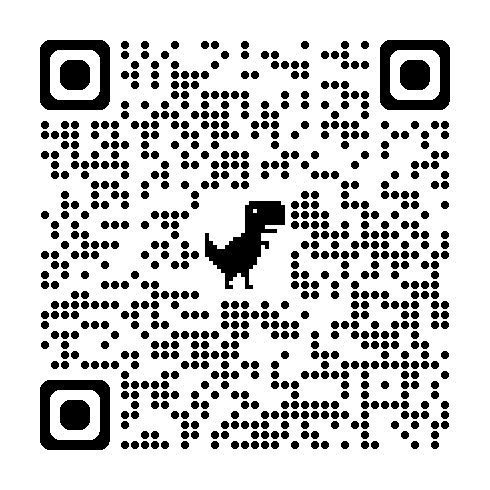

In [ ]:
# @title 📋 Feuille de présence (remplir maintenant)
from IPython.display import Image, display, HTML

display(HTML('<h3 style="font-family:sans-serif;">📋 Feuille de présence</h3>'))
display(Image("https://raw.githubusercontent.com/Maxencegu/python-datascience-l3/main/assignments/td05_matplotlib_dictionnaires_et_pandas/assets/qr_td05_presence.png", width=250))
display(HTML('<a href="https://forms.gle/K12J25Gtbn7tJw7d6" target="_blank"><button style="font-size:15px;padding:8px 16px;margin-top:8px;cursor:pointer;">Ouvrir le formulaire</button></a>'))

In [ ]:
# @title Configuration des ressources (ne pas modifier)
from IPython.display import Image, display, HTML

BASE_URL = "https://raw.githubusercontent.com/Maxencegu/python-datascience-l3/main/assignments/td05_matplotlib_dictionnaires_et_pandas/images/"

def afficher_infographie(nom_fichier, largeur=1300):
    display(Image(url=BASE_URL + nom_fichier, width=largeur))

# **1. Matplotlib**

La visualisation des données est une compétence clé pour les experts en science des données. Matplotlib facilite la création de graphiques significatifs et pertinents. Dans ce chapitre, vous apprendrez à construire différents types de graphiques et à les personnaliser pour les rendre plus attrayants visuellement et plus faciles à interpréter.

In [ ]:
# @title Infographie — Workflow Complet du TD
afficher_infographie("13_workflow_complet_td_pro.png")

## **1.1 Tracés de base avec Matplotlib**

La visualisation des données est une compétence clé pour les experts en science des données. Matplotlib facilite la création de graphiques significatifs et pertinents. Dans ce chapitre, vous apprendrez à construire différents types de graphiques et à les personnaliser pour les rendre plus attrayants visuellement et plus faciles à interpréter.

In [ ]:
# @title Infographie — Les bases de Matplotlib en Python
afficher_infographie("01_matplotlib_bases_pro.png")

In [ ]:
# @title
# @title# @title CheatSheet sur Python
from IPython.display import HTML, display

URL = "https://raw.githubusercontent.com/Maxencegu/python-datascience-l3/main/resources/python_bases_cheatsheet_pro.png"

display(HTML(f"""
<a href="{URL}" target="_blank" style="text-decoration:none;">
  <button style="
    background:#1f6feb;
    color:white;
    border:none;
    border-radius:8px;
    padding:10px 20px;
    font-size:14px;
    font-weight:600;
    cursor:pointer;
    letter-spacing:0.03em;
  ">📋 Ouvrir la Cheat Sheet Python</button>
</a>
"""))

---
---
### **Exercice**
**Tracé linéaire**

Avec matplotlib, vous pouvez créer un grand nombre de graphiques différents en Python. Le graphique le plus simple est le **graphique linéaire**. Voici la recette générale :

```python
import matplotlib.pyplot as plt
plt.plot(x, y)
plt.show()
```

La Banque mondiale dispose d'estimations de la population mondiale pour les années 1950 à 2100. Les années sont disponibles dans la liste year, les populations correspondantes (en milliards) dans la liste pop.

---

**Instructions**

1. Affichez avec `print()` le dernier élément de la liste year et le dernier élément de la liste pop pour connaître la population prévue pour l'année 2100. Utilisez deux appels `print()` séparés.
2. Importez `matplotlib.pyplot` sous l'alias plt.
3. Utilisez `plt.plot()` pour construire un graphique linéaire : year sur l'axe horizontal, pop sur l'axe vertical. Terminez avec `plt.show()` pour afficher le graphique.

In [ ]:
# @title Cellule à exécuter en premier
# Data — world population (in billions), 1950–2100
year = [1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052, 2053, 2054, 2055, 2056, 2057, 2058, 2059, 2060, 2061, 2062, 2063, 2064, 2065, 2066, 2067, 2068, 2069, 2070, 2071, 2072, 2073, 2074, 2075, 2076, 2077, 2078, 2079, 2080, 2081, 2082, 2083, 2084, 2085, 2086, 2087, 2088, 2089, 2090, 2091, 2092, 2093, 2094, 2095, 2096, 2097, 2098, 2099, 2100]
pop  = [2.53, 2.57, 2.62, 2.67, 2.71, 2.76, 2.81, 2.86, 2.92, 2.97, 3.03, 3.08, 3.14, 3.2, 3.26, 3.33, 3.4, 3.47, 3.54, 3.62, 3.69, 3.77, 3.84, 3.92, 4.0, 4.07, 4.15, 4.22, 4.3, 4.37, 4.45, 4.53, 4.61, 4.69, 4.78, 4.86, 4.95, 5.05, 5.14, 5.23, 5.32, 5.41, 5.49, 5.58, 5.66, 5.74, 5.82, 5.9, 5.98, 6.05, 6.13, 6.2, 6.28, 6.36, 6.44, 6.51, 6.59, 6.67, 6.75, 6.83, 6.92, 7.0, 7.08, 7.16, 7.24, 7.32, 7.4, 7.48, 7.56, 7.64, 7.72, 7.79, 7.87, 7.94, 8.01, 8.08, 8.15, 8.22, 8.29, 8.36, 8.42, 8.49, 8.56, 8.62, 8.68, 8.74, 8.8, 8.86, 8.92, 8.98, 9.04, 9.09, 9.15, 9.2, 9.26, 9.31, 9.36, 9.41, 9.46, 9.5, 9.55, 9.6, 9.64, 9.68, 9.73, 9.77, 9.81, 9.85, 9.88, 9.92, 9.96, 9.99, 10.03, 10.06, 10.09, 10.13, 10.16, 10.19, 10.22, 10.25, 10.28, 10.31, 10.33, 10.36, 10.38, 10.41, 10.43, 10.46, 10.48, 10.5, 10.52, 10.55, 10.57, 10.59, 10.61, 10.63, 10.65, 10.66, 10.68, 10.7, 10.72, 10.73, 10.75, 10.77, 10.78, 10.79, 10.81, 10.82, 10.83, 10.84, 10.85]


2100
10.85


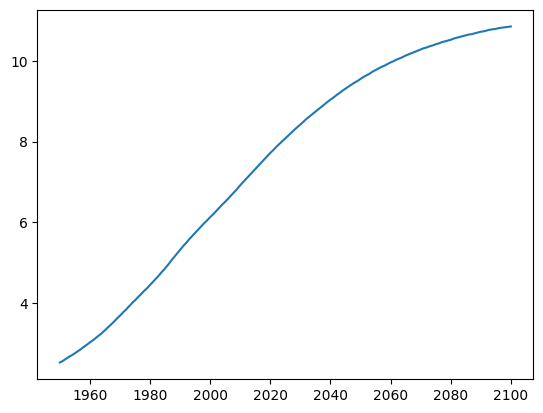

In [ ]:

# Print the last item from year and pop
print(year[-1])
print(pop[-1])

# Import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# Make a line plot: year on the x-axis, pop on the y-axis
plt.plot(year, pop)

# Display the plot with plt.show()
plt.show()

---
---
### **Exercice**

**Tracé linéaire**

Maintenant que vous avez construit votre premier graphique linéaire, commençons à travailler sur les données que le professeur Hans Rosling a utilisées pour construire son magnifique graphique à bulles. Elles ont été collectées en 2007.
Deux listes sont à votre disposition :

- `life_exp` qui contient l'espérance de vie pour chaque pays, et
- `gdp_cap` qui contient le PIB par habitant (par personne) de chaque pays,
  exprimé en dollars américains.

Le PIB (produit intérieur brut) représente essentiellement la taille de l'économie d'un pays. Divisé par la population, on obtient le PIB par habitant.

`matplotlib.pyplot` est déjà importé en tant que `plt`.

---

### **Instructions**

1. Affichez le dernier élément de `gdp_cap` et de `life_exp` — ce sont les données du Zimbabwe.
2. Créez un graphique linéaire avec `gdp_cap` sur l'axe des x et `life_exp` sur
   l'axe des y.
3. Terminez par `plt.show()` pour afficher le graphique.

---

In [ ]:
# @title Cellule à exécuter en premier
gdp_cap = [974.5803384, 5937.029525999999, 6223.367465, 4797.231267, 12779.37964, 34435.367439999995, 36126.4927, 29796.04834, 1391.253792, 33692.60508, 1441.284873, 3822.137084, 7446.298803, 12569.85177, 9065.800825, 10680.79282, 1217.032994, 430.0706916, 1713.778686, 2042.09524, 36319.23501, 706.016537, 1704.063724, 13171.63885, 4959.114854, 7006.580419, 986.1478792, 277.5518587, 3632.557798, 9645.06142, 1544.750112, 14619.222719999998, 8948.102923, 22833.30851, 35278.41874, 2082.4815670000003, 6025.374752000001, 6873.262326000001, 5581.180998, 5728.353514, 12154.08975, 641.3695236000001, 690.8055759, 33207.0844, 30470.0167, 13206.48452, 752.7497265, 32170.37442, 1327.60891, 27538.41188, 5186.050003, 942.6542111, 579.2317429999999, 1201.637154, 3548.3308460000003, 39724.97867, 18008.94444, 36180.78919, 2452.210407, 3540.651564, 11605.71449, 4471.061906, 40675.99635, 25523.2771, 28569.7197, 7320.880262000001, 31656.06806, 4519.461171, 1463.249282, 1593.06548, 23348.139730000003, 47306.98978, 10461.05868, 1569.331442, 414.5073415, 12057.49928, 1044.770126, 759.3499101, 12451.6558, 1042.581557, 1803.151496, 10956.99112, 11977.57496, 3095.7722710000003, 9253.896111, 3820.17523, 823.6856205, 944.0, 4811.060429, 1091.359778, 36797.93332, 25185.00911, 2749.320965, 619.6768923999999, 2013.977305, 49357.19017, 22316.19287, 2605.94758, 9809.185636, 4172.838464, 7408.905561, 3190.481016, 15389.924680000002, 20509.64777, 19328.70901, 7670.122558, 10808.47561, 863.0884639000001, 1598.435089, 21654.83194, 1712.472136, 9786.534714, 862.5407561000001, 47143.17964, 18678.31435, 25768.25759, 926.1410683, 9269.657808, 28821.0637, 3970.095407, 2602.394995, 4513.480643, 33859.74835, 37506.41907, 4184.548089, 28718.27684, 1107.482182, 7458.396326999999, 882.9699437999999, 18008.50924, 7092.923025, 8458.276384, 1056.380121, 33203.26128, 42951.65309, 10611.46299, 11415.80569, 2441.576404, 3025.349798, 2280.769906, 1271.211593, 469.70929810000007]
life_exp = [43.828, 76.423, 72.301, 42.731, 75.32, 81.235, 79.829, 75.635, 64.062, 79.441, 56.728, 65.554, 74.852, 50.728, 72.39, 73.005, 52.295, 49.58, 59.723, 50.43, 80.653, 44.74100000000001, 50.651, 78.553, 72.961, 72.889, 65.152, 46.462, 55.322, 78.782, 48.328, 75.748, 78.273, 76.486, 78.332, 54.791, 72.235, 74.994, 71.33800000000001, 71.878, 51.57899999999999, 58.04, 52.947, 79.313, 80.657, 56.735, 59.448, 79.406, 60.022, 79.483, 70.259, 56.007, 46.388000000000005, 60.916, 70.19800000000001, 82.208, 73.33800000000001, 81.757, 64.69800000000001, 70.65, 70.964, 59.545, 78.885, 80.745, 80.546, 72.567, 82.603, 72.535, 54.11, 67.297, 78.623, 77.58800000000001, 71.993, 42.592, 45.678, 73.952, 59.443000000000005, 48.303, 74.241, 54.467, 64.164, 72.801, 76.195, 66.803, 74.543, 71.164, 42.082, 62.069, 52.906000000000006, 63.785, 79.762, 80.204, 72.899, 56.867, 46.859, 80.196, 75.64, 65.483, 75.53699999999999, 71.752, 71.421, 71.688, 75.563, 78.098, 78.74600000000001, 76.442, 72.476, 46.242, 65.528, 72.777, 63.062, 74.002, 42.568000000000005, 79.972, 74.663, 77.926, 48.159, 49.339, 80.941, 72.396, 58.556, 39.613, 80.884, 81.70100000000001, 74.143, 78.4, 52.517, 70.616, 58.42, 69.819, 73.923, 71.777, 51.542, 79.425, 78.242, 76.384, 73.747, 74.249, 73.422, 62.698, 42.38399999999999, 43.487]

469.70929810000007
43.487


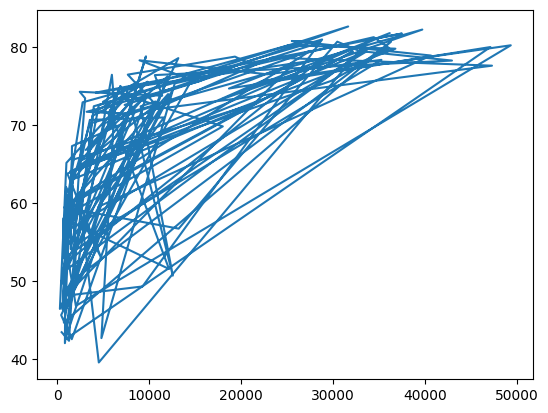

In [ ]:
# Print the last item of gdp_cap and life_exp
print(gdp_cap[-1])
print(life_exp[-1])

# Make a line plot, gdp_cap on the x-axis, life_exp on the y-axis
plt.plot(gdp_cap, life_exp)

# Display the plot
plt.show()

---
---
### **Exercice**

**Diagramme en nuage de points**

Lorsque vous disposez d'une échelle de temps le long de l'axe horizontal, le graphique linéaire est votre ami. Mais dans de nombreux autres cas — lorsque vous évaluez s'il existe une corrélation entre deux variables, par exemple — le diagramme en nuage de points est le meilleur choix. En voici la syntaxe :

```python
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.show()
```

Poursuivons avec le graphique gdp_cap vs life_exp des données Gapminder 2007.
Un nuage de points serait-il une meilleure alternative ?

`matplotlib.pyplot` est disponible en tant que `plt`, et `gdp_cap` / `life_exp`
sont déjà définis.

---
Instructions

1. Remplacez le tracé linéaire par un diagramme en nuage de points.
2. Ajoutez `plt.xscale('log')` pour afficher le PIB sur une échelle logarithmique : la corrélation apparaîtra bien plus clairement.
3. Terminez avec `plt.show()`.

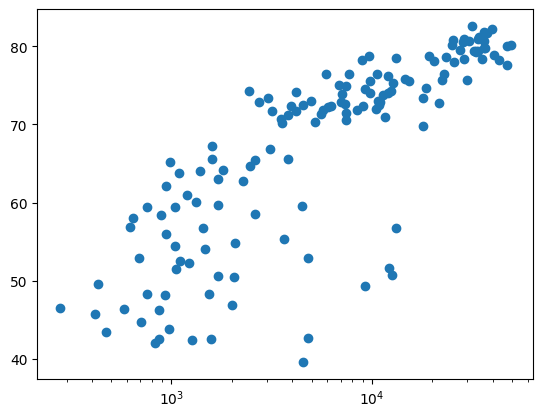

In [ ]:
# Change the line plot below to a scatter plot
plt.scatter(gdp_cap, life_exp)

# Put the x-axis on a logarithmic scale
plt.xscale('log')

# Show plot
plt.show()

---
---
### **Exercice**

**Diagramme en nuage de points**

Dans l'exercice précédent, vous avez vu que plus le PIB est élevé, plus l'espérance de vie est importante — il existe une **corrélation positive**.

Pensez-vous qu'il existe une relation entre la **population** d'un pays et son
**espérance de vie** ? La liste `life_exp` de l'exercice précédent est déjà
disponible. La liste `pop` est désormais définie avec les populations correspondantes pour 2007, exprimées en **millions de personnes**.

---

### **Instructions**

1. Importez `matplotlib.pyplot` en tant que `plt`.
2. Créez un diagramme en nuage de points avec `pop` sur l'axe horizontal et
   `life_exp` sur l'axe vertical.
3. Terminez avec `plt.show()`. Voyez-vous une corrélation ?

In [ ]:
# @title Cellule à exécuter en premier
pop = [31.889923, 3.600523, 33.333216, 12.420476, 40.301927, 20.434176, 8.199783, 0.708573, 150.448339, 10.392226, 8.078314, 9.119152, 4.552198, 1.639131, 190.010647, 7.322858, 14.326203, 8.390505, 14.131858, 17.696293, 33.390141, 4.369038, 10.238807, 16.284741, 1318.683096, 44.22755, 0.71096, 64.606759, 3.80061, 4.133884, 18.013409, 4.493312, 11.416987, 10.228744, 5.46812, 0.496374, 9.319622, 13.75568, 80.264543, 6.939688, 0.551201, 4.906585, 76.511887, 5.23846, 61.083916, 1.454867, 1.688359, 82.400996, 22.873338, 10.70629, 12.572928, 9.947814, 1.472041, 8.502814, 7.483763, 6.980412, 9.956108, 0.301931, 1110.396331, 223.547, 69.45357, 27.499638, 4.109086, 6.426679, 58.147733, 2.780132, 127.467972, 6.053193, 35.610177, 23.301725, 49.04479, 2.505559, 3.921278, 2.012649, 3.193942, 6.036914, 19.167654, 13.327079, 24.821286, 12.031795, 3.270065, 1.250882, 108.700891, 2.874127, 0.684736, 33.757175, 19.951656, 47.76198, 2.05508, 28.90179, 16.570613, 4.115771, 5.675356, 12.894865, 135.031164, 4.627926, 3.204897, 169.270617, 3.242173, 6.667147, 28.674757, 91.077287, 38.518241, 10.642836, 3.942491, 0.798094, 22.276056, 8.860588, 0.199579, 27.601038, 12.267493, 10.150265, 6.144562, 4.553009, 5.447502, 2.009245, 9.118773, 43.997828, 40.448191, 20.378239, 42.292929, 1.133066, 9.031088, 7.554661, 19.314747, 23.174294, 38.13964, 65.068149, 5.701579, 1.056608, 10.276158, 71.158647, 29.170398, 60.776238, 301.139947, 3.447496, 26.084662, 85.262356, 4.018332, 22.211743, 11.746035, 12.311143]

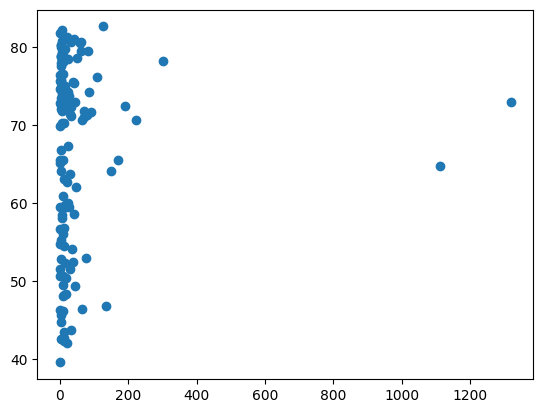

NON


In [ ]:
# Import package
import matplotlib.pyplot as plt

# Build Scatter plot
plt.scatter(pop, life_exp)

# Show plot
plt.show()

# Correlation : OUI ou NON
print("NON")

## **1.2 Histogramme**

In [ ]:
# @title Infographie — Les histogrammes
afficher_infographie("02_histogrammes_pro.png")

---
---
### **Exercice**

**Construire un histogramme (1)**

La liste `life_exp` contient des données sur l'espérance de vie dans différents pays en 2007.

Pour visualiser comment se répartit l'espérance de vie, créons un histogramme de
`life_exp`.

`matplotlib.pyplot` est déjà disponible en tant que `plt`, et `life_exp` est déjà défini.

---

### **Instructions**

1. Utilisez `plt.hist()` pour créer un histogramme des valeurs de `life_exp`. Ne
   spécifiez pas le nombre de classes — Python utilisera 10 par défaut.
2. Ajoutez `plt.show()` pour afficher l'histogramme. Quelle classe contient le plus grand nombre de pays ?

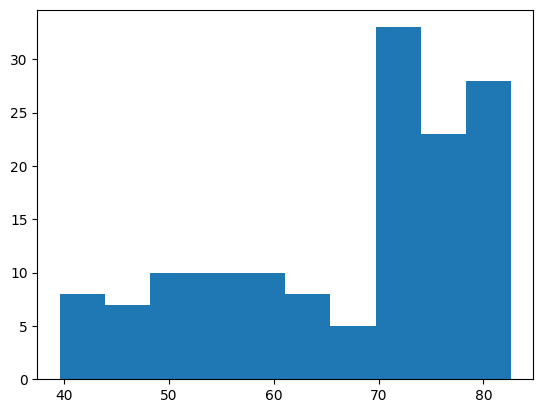

In [ ]:
# Create histogram of life_exp data
plt.hist(life_exp)

# Display histogram
plt.show()

---
---
### **Exercice**

**Construire un histogramme (2) — bins**

Dans l'exercice précédent, vous n'avez pas spécifié le nombre de classes. Python
fixe alors ce nombre à 10 par défaut.

Le choix du nombre de classes est important :
- trop peu de classes → la distribution est trop simplifiée, on perd les détails
- trop de classes → trop de bruit, difficile d'avoir une vue d'ensemble

L'argument `bins` permet de contrôler ce nombre.

Vous ferez ici **deux tracés**. Le code contient déjà les appels `plt.show()` et
`plt.clf()` : `plt.show()` affiche le graphique, `plt.clf()` le réinitialise pour recommencer.

`life_exp` est disponible et `matplotlib.pyplot` est importé en tant que `plt`.

---

### **Instructions**

1. Construisez un histogramme de `life_exp` avec **5 classes**. Quelle classe
   contient le plus grand nombre de pays ?
2. Construisez un second histogramme de `life_exp` avec **20 classes**. Est-ce
   plus lisible ?

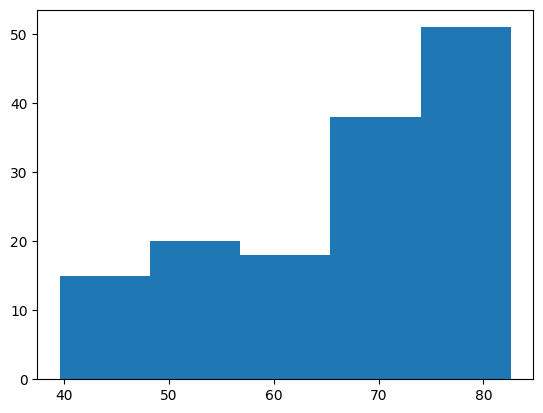

La classe qui contient le plus grand nombre de pays : 5
--------------------------------------------------------


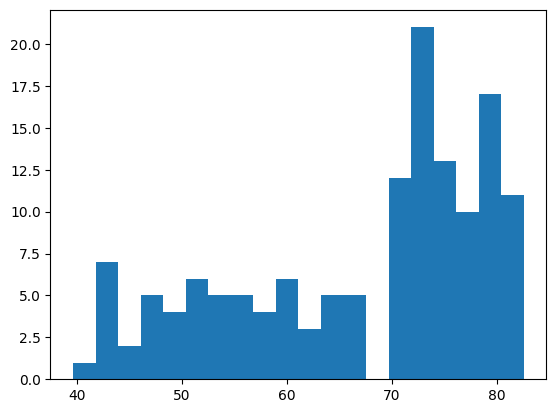

Avec 20 classes, est ce plus lisible: OUI


In [ ]:
# Build histogram with 5 bins
plt.hist(life_exp,bins=5)

# Show and clean up plot
plt.show()
#plt.clf()

print("La classe qui contient le plus grand nombre de pays :", 5)
print("--------------------------------------------------------")

# Build histogram with 20 bins
plt.hist(life_exp,bins=20)

# Show and clean up again
plt.show()
#plt.clf()
print("Avec 20 classes, est ce plus lisible:", "OUI")

---
---
### **Exercice**

**Construire un histogramme (3) — comparer deux distributions**

`life_exp` contient l'espérance de vie par pays en **2007**.
Une deuxième liste `life_exp1950` contient les mêmes données pour **1950**.

Les commandes `plt.show()` et `plt.clf()` sont déjà incluses. `matplotlib.pyplot` est importé en tant que `plt`.

---

### **Instructions**

1. Construisez un histogramme de `life_exp` avec **15 classes**.
2. Construisez un histogramme de `life_exp1950` avec **15 classes**. La différence avec 2007 est-elle importante ?

In [ ]:
# @title Cellule à exécuter en premier
life_exp1950 = [28.8, 55.23, 43.08, 30.02, 62.48, 69.12, 66.8, 50.94, 37.48, 68.0, 38.22, 40.41, 53.82, 47.62, 50.92, 59.6, 31.98, 39.03, 39.42, 38.52, 68.75, 35.46, 38.09, 54.74, 44.0, 50.64, 40.72, 39.14, 42.11, 57.21, 40.48, 61.21, 59.42, 66.87, 70.78, 34.81, 45.93, 48.36, 41.89, 45.26, 34.48, 35.93, 34.08, 66.55, 67.41, 37.0, 30.0, 67.5, 43.15, 65.86, 42.02, 33.61, 32.5, 37.58, 41.91, 60.96, 64.03, 72.49, 37.37, 37.47, 44.87, 45.32, 66.91, 65.39, 65.94, 58.53, 63.03, 43.16, 42.27, 50.06, 47.45, 55.56, 55.93, 42.14, 38.48, 42.72, 36.68, 36.26, 48.46, 33.68, 40.54, 50.99, 50.79, 42.24, 59.16, 42.87, 31.29, 36.32, 41.72, 36.16, 72.13, 69.39, 42.31, 37.44, 36.32, 72.67, 37.58, 43.44, 55.19, 62.65, 43.9, 47.75, 61.31, 59.82, 64.28, 52.72, 61.05, 40.0, 46.47, 39.88, 37.28, 58.0, 30.33, 60.4, 64.36, 65.57, 32.98, 45.01, 64.94, 57.59, 38.64, 41.41, 71.86, 69.62, 45.88, 58.5, 41.22, 50.85, 38.6, 59.1, 44.6, 43.58, 39.98, 69.18, 68.44, 66.07, 55.09, 40.41, 43.16, 32.55, 42.04, 48.45]

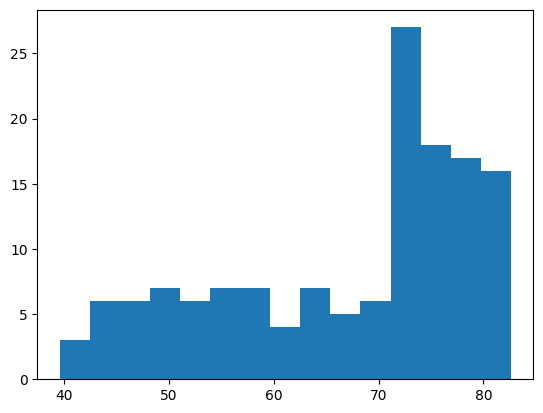

-----------------------------------------------------------------------


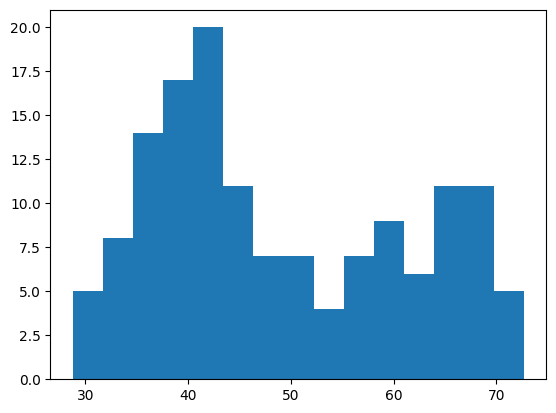

La différence est-elle importante : OUI


<Figure size 640x480 with 0 Axes>

In [ ]:
# Histogram of life_exp, 15 bins
plt.hist(life_exp, 15)

# Show and clear plot
plt.show()
plt.clf()

# Histogram of life_exp1950, 15 bins
plt.hist(life_exp1950, 15)
print("-----------------------------------------------------------------------")

# Show and clear plot again
plt.show()
plt.clf()

print("La différence est-elle importante :", "OUI")

---
---
### **Exercice**

**Choisissez la bonne courbe (1)**

Vous êtes professeur et vous souhaitez évaluer visuellement si les notes de votre examen suivent une distribution particulière. Quelle visualisation utilisez-vous ?

In [ ]:
# @title ⚙️ Préparation de l'exercice (exécuter d'abord)
try:
    del reponse
except NameError:
    pass
print("Environnement pret")

Environnement pret


In [ ]:
# @title 🔧 Exercice — Choisissez la bonne courbe (1)
# ================================================================
#  EXERCICE — Quelle visualisation pour une distribution ?   [ 1 étape ]
# ================================================================
#
# Vous voulez visualiser si les notes d'un examen suivent
# une distribution particulière.
#
#   1 — Graphique linéaire
#   2 — Diagramme en nuage de points
#   3 — Histogramme
#
# ----------------------------------------------------------------
# Entrez le numéro de la bonne réponse (1, 2 ou 3)
# ----------------------------------------------------------------
reponse = 3

In [ ]:
# @title ✅ Exécuter la cellule pour vérifier votre réponse
print("Résultats :\n")

EXPLICATIONS = {
    1: "Incorrect. Le graphique linéaire est adapté pour suivre l'évolution d'une variable dans le temps, pas pour visualiser une distribution.",
    2: "Incorrect. Le nuage de points sert à évaluer la corrélation entre deux variables numériques.",
    3: "Correct ! L'histogramme est l'outil idéal pour visualiser la distribution d'une variable numérique et voir si elle suit une forme particulière (cloche, asymétrie, etc.).",
}

try:
    r = int(reponse)
    if r == 3:
        print(f"  ✅ Bonne réponse ({r}) : {EXPLICATIONS[r]}")
    elif r in EXPLICATIONS:
        print(f"  ❌ Réponse {r} incorrecte : {EXPLICATIONS[r]}")
    else:
        print(f"  ❌ Réponse non reconnue : {reponse!r} — attendu 1, 2 ou 3")
except NameError:
    print("  ❌ reponse n'est pas défini — attribuez un nombre à la variable reponse")
except (ValueError, TypeError):
    print(f"  ❌ reponse doit être un nombre (1, 2 ou 3) — valeur reçue : {reponse!r}")

Résultats :

  ✅ Bonne réponse (3) : Correct ! L'histogramme est l'outil idéal pour visualiser la distribution d'une variable numérique et voir si elle suit une forme particulière (cloche, asymétrie, etc.).


---
---
### **Exercice**

**Choisissez la bonne courbe (2)**

Vous êtes professeur et vous souhaitez évaluer visuellement si les réponses plus
longues aux questions d'examen conduisent à de meilleures notes. Quelle
visualisation utilisez-vous ?

In [ ]:
# @title ⚙️ Préparation de l'exercice (exécuter d'abord)
try:
    del reponse
except NameError:
    pass
print("Environnement pret")

Environnement pret


In [ ]:
# @title 🔧 Exercice — Choisissez la bonne courbe (2)
# ================================================================
#  EXERCICE — Quelle visualisation pour une corrélation ?    [ 1 étape ]
# ================================================================
#
# Vous voulez savoir si la longueur des réponses est liée
# aux notes obtenues à l'examen.
#
#   1 — Graphique linéaire
#   2 — Diagramme en nuage de points
#   3 — Histogramme
#
# ----------------------------------------------------------------
# Entrez le numéro de la bonne réponse (1, 2 ou 3)
# ----------------------------------------------------------------
reponse = 2

In [ ]:
# @title ✅ Exécuter la cellule pour vérifier votre réponse
print("Résultats :\n")

EXPLICATIONS = {
    1: "Incorrect. Le graphique linéaire est adapté pour suivre l'évolution d'une variable dans le temps.",
    2: "Correct ! Le nuage de points est l'outil idéal pour évaluer visuellement la corrélation entre deux variables numériques — ici la longueur des réponses et les notes.",
    3: "Incorrect. L'histogramme visualise la distribution d'une seule variable, pas la relation entre deux variables.",
}

try:
    r = int(reponse)
    if r == 2:
        print(f"  ✅ Bonne réponse ({r}) : {EXPLICATIONS[r]}")
    elif r in EXPLICATIONS:
        print(f"  ❌ Réponse {r} incorrecte : {EXPLICATIONS[r]}")
    else:
        print(f"  ❌ Réponse non reconnue : {reponse!r} — attendu 1, 2 ou 3")
except NameError:
    print("  ❌ reponse n'est pas défini — attribuez un nombre à la variable reponse")
except (ValueError, TypeError):
    print(f"  ❌ reponse doit être un nombre (1, 2 ou 3) — valeur reçue : {reponse!r}")

Résultats :

  ✅ Bonne réponse (2) : Correct ! Le nuage de points est l'outil idéal pour évaluer visuellement la corrélation entre deux variables numériques — ici la longueur des réponses et les notes.


## **1.3 Personnalisation**

In [ ]:
# @title Infographie — Personnalisation
afficher_infographie("03_personnalisation_pro.png")

---
---
### **Exercice**

**Étiquettes**

Vous travaillez sur le diagramme de dispersion des données Gapminder 2007 :
PIB par habitant (`gdp_cap`) sur l'axe des x (échelle logarithmique) et espérance de vie (`life_exp`) sur l'axe des y.

Ajoutons des étiquettes d'axe et un titre. Les fonctions `xlabel()`, `ylabel()` et `title()` sont disponibles via `plt` déjà importé.

`gdp_cap` et `life_exp` sont déjà définis.

---

### **Instructions**

1. `xlab` et `ylab` sont déjà définis. Utilisez-les pour étiqueter les axes x et y.
2. `title` est également défini. Utilisez-le pour ajouter un titre au graphique.
3. Terminez avec `plt.show()`.

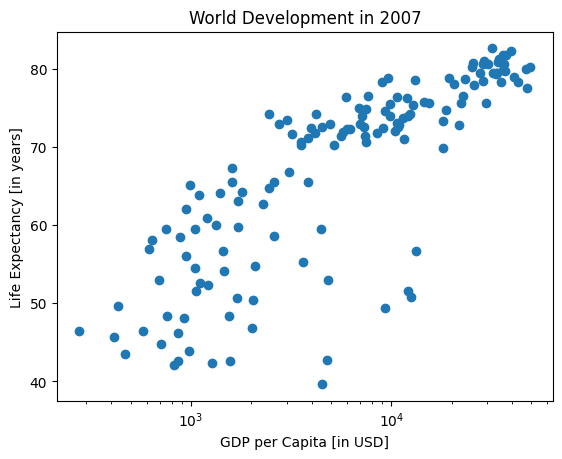

In [ ]:
# Basic scatter plot, log scale
plt.scatter(gdp_cap, life_exp)
plt.xscale('log')

# Strings
xlab = 'GDP per Capita [in USD]'
ylab = 'Life Expectancy [in years]'
title = 'World Development in 2007'

# Add axis labels
plt.xlabel(xlab)
plt.ylabel(ylab)

# Add title
plt.title(title)

# After customizing, display the plot
plt.show()

---
---
### **Exercice**

**Coches (ticks)**

Les personnalisations précédentes (scatter plot, échelle log, étiquettes, titre) sont
déjà incluses dans le code ci-dessous.

Dans le cours, vous avez vu comment contrôler les graduations avec deux arguments :

```python
plt.yticks([0, 1, 2], ["one", "two", "three"])
```

Faisons la même chose pour l'axe des x avec xticks(). Les valeurs 1000, 10000
et 100000 doivent s'afficher sous la forme 1k, 10k et 100k. Les deux listes
tick_val et tick_lab sont déjà définies.

---

### **Instructions**

1. Utilisez tick_val et tick_lab comme arguments de plt.xticks() pour rendre
le graphique plus lisible.
2. Affichez le graphique avec plt.show().

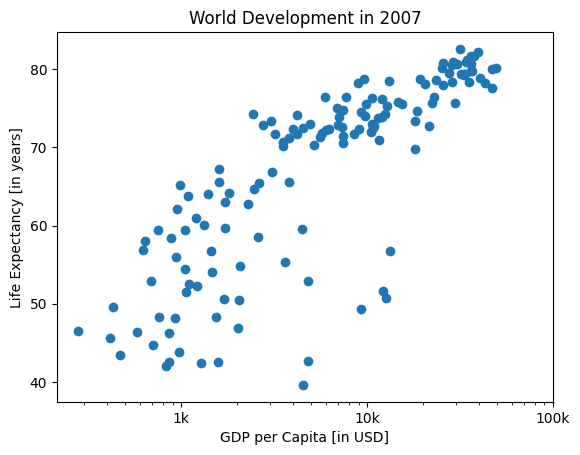

In [ ]:
# Scatter plot
plt.scatter(gdp_cap, life_exp)

# Previous customizations
plt.xscale('log')
plt.xlabel('GDP per Capita [in USD]')
plt.ylabel('Life Expectancy [in years]')
plt.title('World Development in 2007')

# Definition of tick_val and tick_lab
tick_val = [1000, 10000, 100000]
tick_lab = ['1k', '10k', '100k']

# Adapt the ticks on the x-axis
plt.xticks(tick_val, tick_lab)

# After customizing, display the plot
plt.show()

---
---
### **Exercice**

**Tailles**

Pour l'instant le diagramme est un simple nuage de points bleus. Et si la taille de
chaque bulle correspondait à la population du pays ?

La liste `pop` (populations en millions) est disponible et passée à `plt.scatter()`
via l'argument `s` (size). Toutes les personnalisations précédentes sont déjà
incluses dans le code.

---

### **Instructions**

1. Exécutez d'abord le script tel quel pour observer le résultat avec `s=pop`.
2. Améliorez ensuite la lisibilité en grossissant les bulles :
   - Importez `numpy` en tant que `np`.
   - Créez un tableau NumPy `np_pop` à partir de la liste `pop` avec `np.array()`.
   - Doublez les valeurs : `np_pop = np_pop * 2`.
   - Remplacez `s=pop` par `s=np_pop` dans `plt.scatter()`.

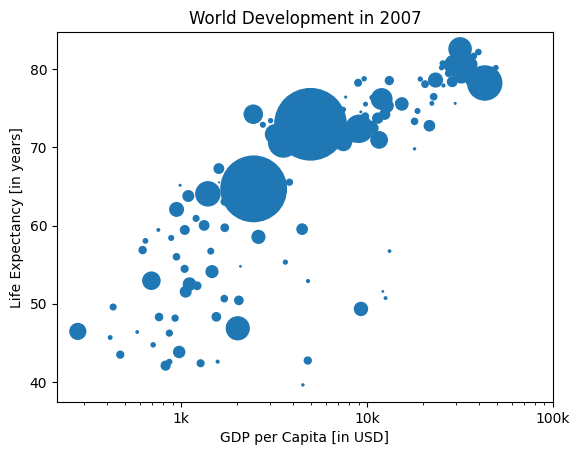

In [ ]:
# Import numpy as np
import numpy as np

# Store pop as a numpy array: np_pop
np_pop = np.array(pop)

# Double np_pop
np_pop = np_pop * 2

# Update: set s argument to np_pop
plt.scatter(gdp_cap, life_exp, s = np_pop)

# Previous customizations
plt.xscale('log')
plt.xlabel('GDP per Capita [in USD]')
plt.ylabel('Life Expectancy [in years]')
plt.title('World Development in 2007')
plt.xticks([1000, 10000, 100000],['1k', '10k', '100k'])

# Display the plot
plt.show()

---
---
### **Exercice**

**Couleurs**

Le code précédent est déjà inclus. Ajoutons de la couleur : chaque pays reçoit une couleur selon son continent, définie dans la liste `col`.

| Continent | Couleur |
|-----------|---------|
| Asia      | red     |
| Europe    | green   |
| Africa    | blue    |
| Americas  | yellow  |
| Oceania   | black   |

Ne vous inquiétez pas pour la construction de `col` — vous découvrirez les
dictionnaires dans le prochain chapitre.

---

### **Instructions**

1. Ajoutez `c=col` aux arguments de `plt.scatter()` pour colorier les bulles.
2. Ajoutez `alpha=0.8` pour rendre les bulles légèrement transparentes (0 = invisible, 1 = opaque).

In [ ]:
# @title Cellule à exécuter en premier
col = ['red', 'green', 'blue', 'blue', 'yellow', 'black', 'green', 'red', 'red', 'green', 'blue', 'yellow', 'green', 'blue', 'yellow', 'green', 'blue', 'blue', 'red', 'blue', 'yellow', 'blue', 'blue', 'yellow', 'red', 'yellow', 'blue', 'blue', 'blue', 'yellow', 'blue', 'green', 'yellow', 'green', 'green', 'blue', 'yellow', 'yellow', 'blue', 'yellow', 'blue', 'blue', 'blue', 'green', 'green', 'blue', 'blue', 'green', 'blue', 'green', 'yellow', 'blue', 'blue', 'yellow', 'yellow', 'red', 'green', 'green', 'red', 'red', 'red', 'red', 'green', 'red', 'green', 'yellow', 'red', 'red', 'blue', 'red', 'red', 'red', 'red', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'yellow', 'red', 'green', 'blue', 'blue', 'red', 'blue', 'red', 'green', 'black', 'yellow', 'blue', 'blue', 'green', 'red', 'red', 'yellow', 'yellow', 'yellow', 'red', 'green', 'green', 'yellow', 'blue', 'green', 'blue', 'blue', 'red', 'blue', 'green', 'blue', 'red', 'green', 'green', 'blue', 'blue', 'green', 'red', 'blue', 'blue', 'green', 'green', 'red', 'red', 'blue', 'red', 'blue', 'yellow', 'blue', 'green', 'blue', 'green', 'yellow', 'yellow', 'yellow', 'red', 'red', 'red', 'blue', 'blue']


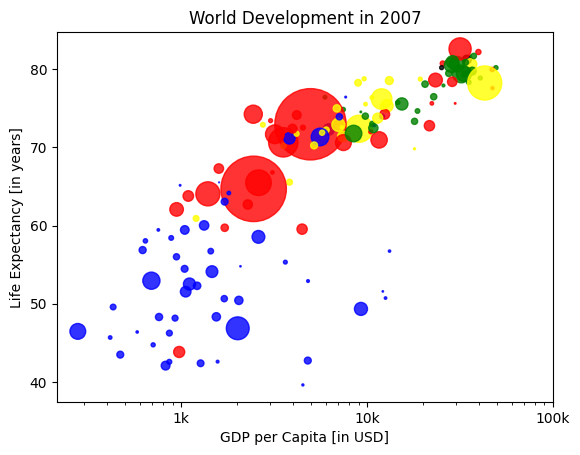

In [ ]:
# Specify c and alpha inside plt.scatter()
plt.scatter(x = gdp_cap, y = life_exp, s = np.array(pop) * 2, c=col, alpha=0.8)

# Previous customizations
plt.xscale('log')
plt.xlabel('GDP per Capita [in USD]')
plt.ylabel('Life Expectancy [in years]')
plt.title('World Development in 2007')
plt.xticks([1000,10000,100000], ['1k','10k','100k'])

# Show the plot
plt.show()

---
---
### **Exercice**

**Personnalisations supplémentaires**

Le code complet est disponible ci-dessous. Deux appels `plt.text()` ont été ajoutés pour annoter directement deux pays sur le graphique :

```python
plt.text(x, y, "label")  # place "label" aux coordonnées (x, y)
```
---
Instructions

1. Ajoutez plt.grid(True) après les appels à plt.text() pour afficher le
quadrillage sur le graphique.

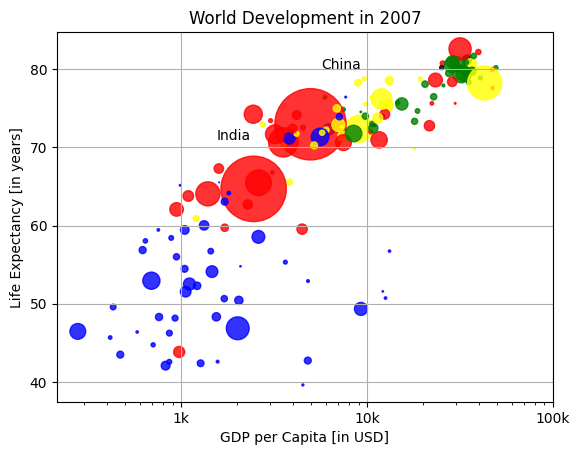

In [ ]:
# Scatter plot
plt.scatter(x = gdp_cap, y = life_exp, s = np.array(pop) * 2, c = col, alpha = 0.8)

# Previous customizations
plt.xscale('log')
plt.xlabel('GDP per Capita [in USD]')
plt.ylabel('Life Expectancy [in years]')
plt.title('World Development in 2007')
plt.xticks([1000,10000,100000], ['1k','10k','100k'])

# Additional customizations
plt.text(1550, 71, 'India')
plt.text(5700, 80, 'China')

# Add grid() call
plt.grid(True)

# Show the plot
plt.show()

# **2. Dictionnaires et Pandas**  

Découvrez le dictionnaire, une alternative à la liste Python, et le DataFrame pandas, la norme de facto pour travailler avec des données tabulaires en Python. Vous aurez l'occasion de vous exercer à la création et à la manipulation d'ensembles de données, et vous apprendrez à accéder aux informations dont vous avez besoin à partir de ces structures de données.

## **2.1 Dictionnaires partie 1**

In [ ]:
# @title Infographie — Dictionnaires partie 1
afficher_infographie("04_dictionnaires_pro.png")

---
---
### **Exercice**

**Motivation pour les dictionnaires**

Les deux listes ci-dessous associent des pays européens à leurs capitales.
`countries` contient les noms des pays, `capitals` les capitales correspondantes, dans le même ordre.

---

### **Instructions**

1. Utilisez la méthode `index()` sur `countries` pour trouver l'indice de
   `'germany'`. Stockez le résultat dans `ind_ger`.
2. Utilisez `ind_ger` pour accéder à la capitale correspondante dans `capitals`
   et affichez-la.

In [ ]:
# Definition of countries and capital
countries = ['spain', 'france', 'germany', 'norway']
capitals = ['madrid', 'paris', 'berlin', 'oslo']

# Get index of 'germany': ind_ger
ind_ger = countries.index('germany')

# Use ind_ger to print out capital of Germany
print(capitals[ind_ger])

berlin


---
---
### **Exercice**

**Créer un dictionnaire**

Les listes `countries` et `capitals` sont à nouveau disponibles. Convertissez ces données en dictionnaire où les noms de pays sont les **clés** et les capitales les **valeurs**.

Rappel de la syntaxe :

```python
my_dict = {
    "key1": "value1",
    "key2": "value2",
}
```

---
### **Instructions**

1. Créez un dictionnaire europe avec 4 paires clé:valeur à partir de countries
et capitals. Utilisez uniquement des minuscules.
2. Affichez europe.

In [ ]:
# Definition of countries and capital
countries = ['spain', 'france', 'germany', 'norway']
capitals = ['madrid', 'paris', 'berlin', 'oslo']

# From string in countries and capitals, create dictionary europe
europe = {'spain':'madrid', 'france': 'paris', 'germany': 'berlin', 'norway': 'oslo'}

# Print europe
print(europe)

{'spain': 'madrid', 'france': 'paris', 'germany': 'berlin', 'norway': 'oslo'}


---
---
### **Exercice**

**Accéder au dictionnaire**

Le dictionnaire `europe` est déjà défini. Pour accéder à une valeur, il suffit de passer la clé entre crochets :

```python
europe['france']  # → 'paris'
```

---
### **Instructions**

1. Affichez toutes les clés de europe en appelant la méthode keys().
2. Affichez la valeur associée à la clé 'norway'.

In [ ]:
# Definition of dictionary
europe = {'spain':'madrid', 'france':'paris', 'germany':'berlin', 'norway':'oslo' }

# Print out the keys in europe
print(europe.keys())

# Print out value that belongs to key 'norway'
print(europe['norway'])

dict_keys(['spain', 'france', 'germany', 'norway'])
oslo


## **2.2 Dictionnaires partie 2**

In [ ]:
# @title Infographie — Dictionnaires partie 2
afficher_infographie("05_dictionnaires_2_pro.png")

---
---
### **Exercice**

**Manipulation de dictionnaire (1)**

Le dictionnaire `europe` est déjà défini. Pour ajouter une nouvelle paire clé:valeur, la syntaxe est :

```python
europe['iceland'] = 'reykjavik'
```

---
### **Instructions**

1. Ajoutez la clé 'italy' avec la valeur 'rome' à europe.
2. Affichez 'italy' in europe pour vérifier que la clé a bien été ajoutée.
3. Ajoutez la paire 'poland' : 'warsaw' à europe.
4. Affichez europe.

In [ ]:
# Definition of dictionary
europe = {'spain':'madrid', 'france':'paris', 'germany':'berlin', 'norway':'oslo' }

# Add italy to europe
europe['italy'] = 'rome'

# Print out italy in europe
print('italy' in europe)

# Add poland to europe
europe['poland'] = 'warsaw'

# Print europe
print(europe)

True
{'spain': 'madrid', 'france': 'paris', 'germany': 'berlin', 'norway': 'oslo', 'italy': 'rome', 'poland': 'warsaw'}


---
---
### **Exercice**

**Manipulation de dictionnaire (2)**

Le dictionnaire `europe` ci-dessous contient deux erreurs. Corrigez-les en ajoutant des commandes Python **après** la définition — ne modifiez pas le dictionnaire directement.

---

### **Instructions**

1. La capitale de l'Allemagne n'est pas `'bonn'` mais `'berlin'`. Corrigez la valeur.
2. L'Australie n'est pas en Europe. Supprimez la clé `'australia'`.
3. Affichez `europe`.

In [ ]:
# Definition of dictionary
europe = {'spain':'madrid', 'france':'paris', 'germany':'bonn',
          'norway':'oslo', 'italy':'rome', 'poland':'warsaw',
          'australia':'vienna' }

# Update capital of germany
europe['germany'] = 'berlin'

# Remove australia
del europe['australia']

# Print europe
print(europe)

{'spain': 'madrid', 'france': 'paris', 'germany': 'berlin', 'norway': 'oslo', 'italy': 'rome', 'poland': 'warsaw'}


---
---
### **Exercice**

**Dictionariception**

Les dictionnaires peuvent contenir d'autres dictionnaires comme valeurs. Dans cette version de `europe`, chaque pays est associé à un dictionnaire avec sa capitale et sa population.

Pour accéder à la population de l'Espagne :

```python
europe['spain']['population']  # → 46.77
```

---
### **Instructions**

1. Affichez la capitale de la France en enchaînant deux paires de crochets.
2. Créez un dictionnaire data avec les clés 'capital' (valeur : 'rome') et
'population' (valeur : 59.83).
3. Ajoutez 'italy' à europe avec data comme valeur.

In [ ]:
# Dictionary of dictionaries
europe = { 'spain': { 'capital':'madrid', 'population':46.77 },
           'france': { 'capital':'paris', 'population':66.03 },
           'germany': { 'capital':'berlin', 'population':80.62 },
           'norway': { 'capital':'oslo', 'population':5.084 } }


# Print out the capital of France
print(europe['france']['capital'])

# Create sub-dictionary data
data = {'capital':'rome', 'population':59.83}

# Add data to europe under key 'italy'
europe['italy'] = data

# Print europe
print(europe)

[ 70 195]
75


## **2.3 Pandas partie 1**

In [ ]:
# @title Infographie — Pandas partie 1
afficher_infographie("06_pandas_dataframes_pro.png")

---
---
### **Exercice**

**Dictionnaire vers DataFrame (1)**

Pandas est une bibliothèque Open Source qui fournit des structures de données performantes pour Python. Le **DataFrame** est l'une de ses structures clés : un tableau dont on peut étiqueter les lignes et les colonnes.

Une façon de créer un DataFrame est de partir d'un dictionnaire où chaque clé est un nom de colonne et chaque valeur est une liste :

```python
pd.DataFrame({'col1': [1, 2], 'col2': [3, 4]})
```

Trois listes sont déjà définies :
- names — noms des pays
- dr — True si on conduit à droite, False à gauche
- cpc — nombre de véhicules à moteur pour 1 000 personnes

---

### **Instructions**

1. Importez pandas en tant que pd.
2. Créez un dictionnaire my_dict avec trois paires clé-valeur : 'country' → names, 'drives_right' → dr, 'cars_per_cap' → cpc.
3. Transformez my_dict en DataFrame appelé cars avec pd.DataFrame().
4. Affichez cars.

In [ ]:
# Pre-defined lists
names = ['United States', 'Australia', 'Japan', 'India', 'Russia', 'Morocco', 'Egypt']
dr =  [True, False, False, False, True, True, True]
cpc = [809, 731, 588, 18, 200, 70, 45]

# Import pandas as pd
import pandas as pd

# Create dictionary my_dict with three key:value pairs: my_dict
my_dict = {"country": names, "drives_right": dr, "cars_per_cap": cpc}

# Build a DataFrame cars from my_dict: cars
cars = pd.DataFrame(my_dict)

# Print carsion
print(cars)

         country  drives_right  cars_per_cap
0  United States          True           809
1      Australia         False           731
2          Japan         False           588
3          India         False            18
4         Russia          True           200
5        Morocco          True            70
6          Egypt          True            45


---
---
### **Exercice**

**Dictionnaire vers DataFrame (2)**

Le code de l'exercice précédent est déjà inclus. Avez-vous remarqué que les en-têtes de lignes ont été automatiquement définies comme des entiers (0 à 6) ?

Pour corriger cela, on peut modifier l'attribut `index` du DataFrame :

```python
cars.index = ['US', 'AUS', ...]
```

Une liste row_labels a déjà été créée pour vous.

---
### **Instructions**

1. Affichez cars une première fois pour constater que les étiquettes de lignes ne sont pas correctes.
2. Assignez row_labels à cars.index pour corriger les étiquettes.
3. Affichez cars à nouveau et vérifiez que les en-têtes sont correctes.

In [ ]:
import pandas as pd

# Build cars DataFrame
names = ['United States', 'Australia', 'Japan', 'India', 'Russia', 'Morocco', 'Egypt']
dr =  [True, False, False, False, True, True, True]
cpc = [809, 731, 588, 18, 200, 70, 45]
cars_dict = { 'country':names, 'drives_right':dr, 'cars_per_cap':cpc }
cars = pd.DataFrame(cars_dict)
print(cars)

# Definition of row_labels
row_labels = ['US', 'AUS', 'JPN', 'IN', 'RU', 'MOR', 'EG']

# Specify row labels of cars
cars.index = row_labels

# Print cars again
print(cars)

         country  drives_right  cars_per_cap
0  United States          True           809
1      Australia         False           731
2          Japan         False           588
3          India         False            18
4         Russia          True           200
5        Morocco          True            70
6          Egypt          True            45
           country  drives_right  cars_per_cap
US   United States          True           809
AUS      Australia         False           731
JPN          Japan         False           588
IN           India         False            18
RU          Russia          True           200
MOR        Morocco          True            70
EG           Egypt          True            45


---
---
### **Exercice**

**CSV vers DataFrame (1)**

Construire un DataFrame depuis un dictionnaire fonctionne, mais ce n'est pas pratique pour des millions d'observations. En pratique, les données sont souvent disponibles dans des fichiers **CSV** (*Comma Separated Values*).

Pour importer un fichier CSV dans Pandas :

```python
df = pd.read_csv('fichier.csv')
```

Le fichier cars.csv est déjà disponible dans votre répertoire de travail.

---
### **Instructions**

1. Importez pandas en tant que pd.
2. Utilisez pd.read_csv() pour importer cars.csv dans un DataFrame appelé cars.
3. Affichez cars. Tout semble-t-il en ordre ?

In [ ]:
# @title Cellule à exécuter en premier
import urllib.request
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/Maxencegu/python-datascience-l3/main/datasets/cars.csv",
    "cars.csv"
)

('cars.csv', <http.client.HTTPMessage at 0x7d5bd0f98950>)

In [ ]:
# Import pandas as pd
import pandas as pd

# Import the cars.csv data: cars
cars = pd.read_csv('cars.csv')

# Print out cars
print(cars)

  Unnamed: 0  cars_per_cap        country  drives_right
0         US           809  United States          True
1        AUS           731      Australia         False
2        JPN           588          Japan         False
3         IN            18          India         False
4         RU           200         Russia          True
5        MOR            70        Morocco          True
6         EG            45          Egypt          True


---
---
### **Exercice**

**CSV vers DataFrame (2)**

L'appel à `read_csv()` de l'exercice précédent ne génère pas d'erreur, mais le résultat n'est pas tout à fait correct : les étiquettes de lignes ont été importées comme une colonne sans nom.

L'argument `index_col` de `read_csv()` permet de spécifier quelle colonne doit servir d'étiquettes de lignes :

```python
pd.read_csv('fichier.csv', index_col=0)
```

Le code de l'exercice précédent est déjà inclus.

---
### **Instructions**

1. Affichez cars une première fois pour constater le problème (colonne sans nom en trop).
2. Ajoutez l'argument index_col=0 dans pd.read_csv() pour que la première colonne serve d'étiquettes de lignes.
3. Affichez cars à nouveau et vérifiez que le résultat est correct.

In [ ]:
# Import pandas as pd
import pandas as pd

# Fix import by including index_col
cars = pd.read_csv('cars.csv', index_col=0)

# Print out cars
print(cars)

     cars_per_cap        country  drives_right
US            809  United States          True
AUS           731      Australia         False
JPN           588          Japan         False
IN             18          India         False
RU            200         Russia          True
MOR            70        Morocco          True
EG             45          Egypt          True


## **2.4 Pandas partie 2**

In [ ]:
# @title Infographie — Pandas partie 2
afficher_infographie("07_pandas_indexation_pro.png")

---
---
### **Exercice**

**Crochets (1)**

Il existe plusieurs façons de sélectionner des données dans un DataFrame Pandas. La plus simple utilise les **crochets**.

Pour sélectionner une colonne, la syntaxe diffère selon le type de résultat souhaité :

```python
cars['cars_per_cap']    # → Series  (1 paire de crochets)
cars[['cars_per_cap']]  # → DataFrame (2 paires de crochets)
```
---
### **Instructions**

1. Utilisez des crochets simples pour afficher la colonne country de cars sous forme de Series.
2. Utilisez des doubles crochets pour afficher la colonne country de cars sous forme de DataFrame.
3. Utilisez des doubles crochets pour afficher un DataFrame avec les colonnes country et drives_right, dans cet ordre.

In [ ]:
# Import cars data
import pandas as pd
cars = pd.read_csv('cars.csv', index_col = 0)

# Print out country column as Pandas Series
print(cars['country'])

# Print out country column as Pandas DataFrame
print(cars[['country']])

# Print out DataFrame with country and drives_right columns
print(cars[['country', 'drives_right']])

US     United States
AUS        Australia
JPN            Japan
IN             India
RU            Russia
MOR          Morocco
EG             Egypt
Name: country, dtype: object
           country
US   United States
AUS      Australia
JPN          Japan
IN           India
RU          Russia
MOR        Morocco
EG           Egypt
           country  drives_right
US   United States          True
AUS      Australia         False
JPN          Japan         False
IN           India         False
RU          Russia          True
MOR        Morocco          True
EG           Egypt          True


---
---
### **Exercice**

**Crochets (2)**

Les crochets permettent aussi de sélectionner des **lignes** avec une tranche :

```python
cars[0:5]  # → les 5 premières lignes
```

Le résultat est un DataFrame. Attention : cette syntaxe utilise les indices entiers des lignes (pas les étiquettes), et nécessite obligatoirement une tranche — pas un entier seul.

---
### **Instructions**

1. Sélectionnez les 3 premières observations de cars et affichez-les.
2. Sélectionnez les 4e, 5e et 6e observations (indices 3, 4 et 5) et affichez-les.

In [ ]:
# Import cars data
import pandas as pd
cars = pd.read_csv('cars.csv', index_col = 0)

# Print out first 3 observations
print(cars[:3])

# Print out fourth, fifth and sixth observation
print(cars[3:6])

     cars_per_cap        country  drives_right
US            809  United States          True
AUS           731      Australia         False
JPN           588          Japan         False
     cars_per_cap  country  drives_right
IN             18    India         False
RU            200   Russia          True
MOR            70  Morocco          True


---
---
### **Exercice**

**loc et iloc (1)**

`loc` sélectionne par **étiquette**, `iloc` par **position entière**. Ces deux paires de commandes donnent le même résultat :

```python
cars.loc['RU']     # → Series
cars.loc[['RU']]   # → DataFrame

cars.iloc[4]       # → Series  (même ligne que 'RU')
cars.iloc[[4]]     # → DataFrame
```
---
### **Instructions**

1. Utilisez loc ou iloc pour sélectionner l'observation correspondant au Japon sous forme de Series (étiquette : JPN, indice : 2). Affichez le résultat.
2. Utilisez loc ou iloc pour sélectionner les observations de l'Australie et de l'Égypte sous forme de DataFrame. Affichez le résultat.

In [ ]:
# Import cars data
import pandas as pd
cars = pd.read_csv('cars.csv', index_col = 0)

# Print out observation for Japan
print(cars.loc['JPN'])

# Print out observations for Australia and Egypt
print(cars.loc[['AUS','EG']])

cars_per_cap      588
country         Japan
drives_right    False
Name: JPN, dtype: object
     cars_per_cap    country  drives_right
AUS           731  Australia         False
EG             45      Egypt          True


---
---
### **Exercice**

**loc et iloc (2)**

`loc` et `iloc` permettent de sélectionner simultanément des **lignes et des colonnes** en séparant leur sélection par une virgule :

```python
cars.loc['IN', 'cars_per_cap']          # → valeur unique
cars.loc[['IN', 'RU'], 'cars_per_cap']  # → Series
cars.loc[['IN', 'RU'], ['cars_per_cap', 'country']]  # → DataFrame
```
---
### **Instructions**

1. Affichez la valeur drives_right de la ligne correspondant au Maroc (étiquette : MOR).
2. Affichez un sous-DataFrame avec les observations de la Russie et du Maroc, et les colonnes country et drives_right.

In [ ]:
# Import cars data
import pandas as pd
cars = pd.read_csv('cars.csv', index_col = 0)

# Print out drives_right value of Morocco
print(cars.loc['MOR', 'drives_right'])

# Print sub-DataFrame
print(cars.loc[['RU','MOR'],['country','drives_right']])

True
     country  drives_right
RU    Russia          True
MOR  Morocco          True


---
---
### **Exercice**

**loc et iloc (3)**

Pour sélectionner uniquement des **colonnes** avec `loc` ou `iloc`, on utilise `:` (toutes les lignes) avant la virgule :

```python
cars.loc[:, 'country']            # → Series
cars.loc[:, ['country']]          # → DataFrame
cars.loc[:, ['country', 'drives_right']]  # → DataFrame 2 colonnes
```
---
### **Instructions**

1. Affichez la colonne drives_right sous forme de Series avec loc ou iloc.
2. Affichez la colonne drives_right sous forme de DataFrame avec loc ou iloc.
3. Affichez les colonnes cars_per_cap et drives_right sous forme de DataFrame avec loc ou iloc.

In [ ]:
# Import cars data
import pandas as pd
cars = pd.read_csv('cars.csv', index_col = 0)

# Print out drives_right column as Series
print(cars.loc[:,'drives_right'])

# Print out drives_right column as DataFrame
print(cars.loc[:,['drives_right']])

# Print out cars_per_cap and drives_right as DataFrame
print(cars.loc[:,['cars_per_cap','drives_right']])

US      True
AUS    False
JPN    False
IN     False
RU      True
MOR     True
EG      True
Name: drives_right, dtype: bool
     drives_right
US           True
AUS         False
JPN         False
IN          False
RU           True
MOR          True
EG           True
     cars_per_cap  drives_right
US            809          True
AUS           731         False
JPN           588         False
IN             18         False
RU            200          True
MOR            70          True
EG             45          True


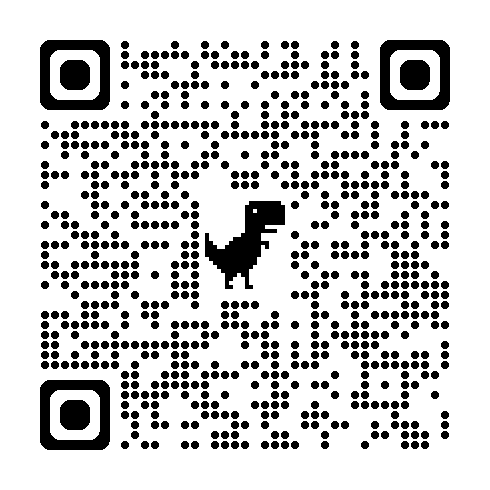

In [ ]:
# @title 🧠 Quiz de fin de séance
from IPython.display import Image, display, HTML

display(HTML('<h3 style="font-family:sans-serif;">🧠 Quiz fin de séance</h3>'))
display(Image("https://raw.githubusercontent.com/Maxencegu/python-datascience-l3/main/assignments/td05_matplotlib_dictionnaires_et_pandas/assets/qr_td05_quiz.png", width=250))
display(HTML('<a href="https://forms.gle/ciYdEWdV8qsubpTn9" target="_blank"><button style="font-size:15px;padding:8px 16px;margin-top:8px;cursor:pointer;">Ouvrir le quiz</button></a>'))